# 🧪 Statistical Tests — Worksheet
**Name:** _______________________   **Date:** _______________________

---
**How this works:**
- Each task gives you a question and a starting line or two
- You write the logic, the test, and the visualisation
- 💡 hints tell you *what* to use — not *how*
- Every chart needs a proper title, xlabel, ylabel — your job

```
p ≤ 0.05 → Reject H₀    |    p > 0.05 → Keep H₀
```
---

In [48]:
!pip install statsmodels

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
np.random.seed(42)
print('Ready')

Ready


---
## 📦 Dataset — Build It

Create a DataFrame called `df` with **200 student records** using these specs:

| Column | Details |
|--------|---------|
| `gender` | Male / Female, random |
| `study_hours` | Normal(mean=4, std=1.2), clipped 0–10 |
| `sleep_hours` | Normal(mean=7, std=1.0), clipped 4–10 |
| `marks` | `study*6 + sleep*2 + noise(0,8)`, clipped 0–100 |
| `subject` | Maths 40%, Science 35%, Arts 25% |
| `passed` | 'Yes' if marks ≥ 50 else 'No' |
| `school` | School A / B / C / D — equal chance |

After creating marks, add a school boost: A:+5, B:0, C:−5, D:+10 (clip to 100).

💡 `np.random.choice` · `np.random.normal` · `.clip()` · `np.where` · `pd.DataFrame`

In [50]:
n = 200

# Gender
gender = np.random.choice(['Male', 'Female'], size=n)

# Study hours
study_hours = np.clip(np.random.normal(4, 1.2, n), 0, 10)

# Sleep hours
sleep_hours = np.clip(np.random.normal(7, 1.0, n), 4, 10)

# Subject
subject = np.random.choice(['Maths', 'Science', 'Arts'], size=n, p=[0.4, 0.35, 0.25])

# School
school = np.random.choice(['School A', 'School B', 'School C', 'School D'], size=n)

# Base marks
marks = study_hours * 6 + sleep_hours * 2 + np.random.normal(0, 8, n)

# School boost
boost = {'School A': 5, 'School B': 0, 'School C': -5, 'School D': 10}
marks = marks + pd.Series(school).map(boost)

# Clip marks
marks = np.clip(marks, 0, 100)

# Passed
passed = np.where(marks >= 50, 'Yes', 'No')

# DataFrame
df = pd.DataFrame({
    'gender': gender,
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'marks': marks,
    'subject': subject,
    'passed': passed,
    'school': school
})

print(df.shape)
df.head()

(200, 7)


,gender,study_hours,sleep_hours,marks,subject,passed,school
0,Male,4.104456,7.199060,28.239375,Maths,No,School B
1,Female,3.641191,6.399783,35.592826,Maths,No,School C
2,Male,4.110113,7.069802,45.167205,Science,No,School A
3,Male,1.614917,6.614686,31.447010,Arts,No,School D
4,Male,3.736394,7.113517,31.792869,Science,No,School C


---
## Task 1 — Explore the Data (Visualisation)

Before any test, look at your data. Create a **2×2 grid of subplots**:
- `[0,0]` Histogram of `marks`
- `[0,1]` Histogram of `study_hours`
- `[1,0]` Boxplot of `marks` by `gender`
- `[1,1]` Boxplot of `marks` by `school`

Label everything. Write one observation below each plot as a comment.

💡 `plt.subplots(2,2)` · `ax.hist()` · `df.boxplot(column, by, ax=)`

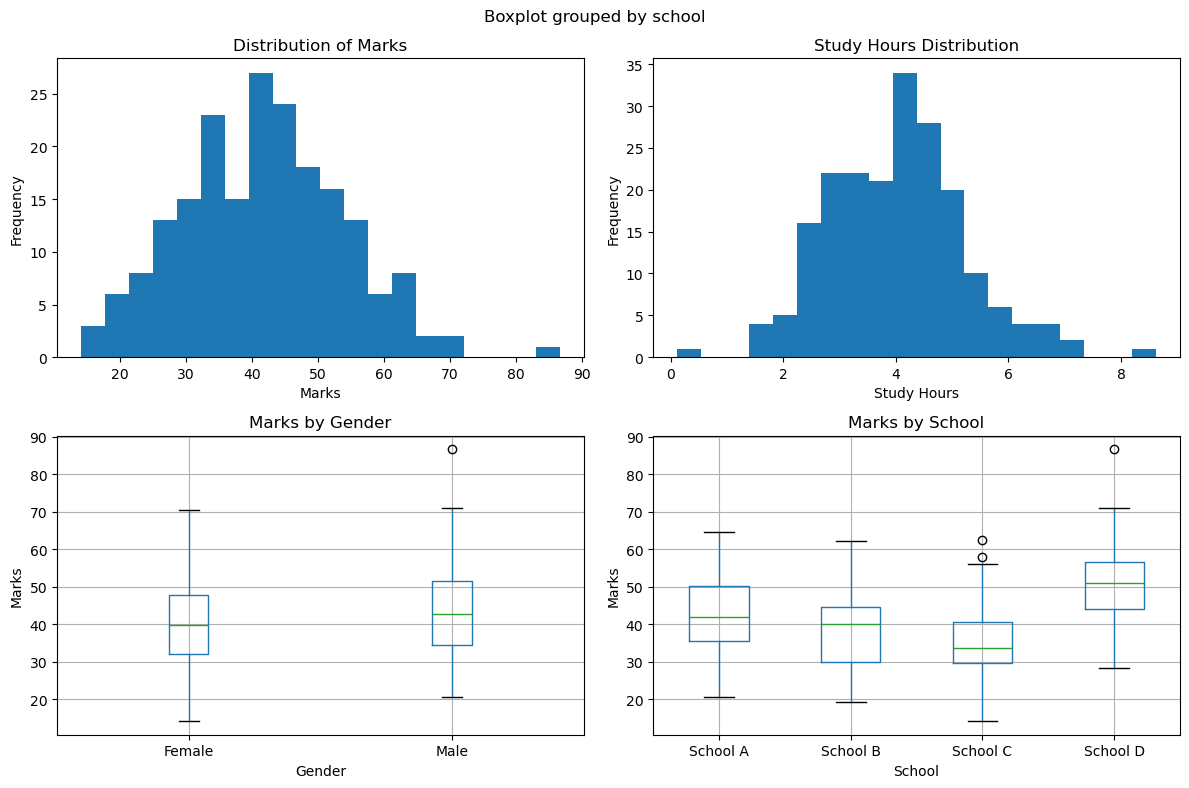

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histogram marks
axes[0,0].hist(df['marks'], bins=20)
axes[0,0].set_title('Distribution of Marks')
axes[0,0].set_xlabel('Marks')
axes[0,0].set_ylabel('Frequency')

# Histogram study hours
axes[0,1].hist(df['study_hours'], bins=20)
axes[0,1].set_title('Study Hours Distribution')
axes[0,1].set_xlabel('Study Hours')
axes[0,1].set_ylabel('Frequency')

# Boxplot gender
df.boxplot(column='marks', by='gender', ax=axes[1,0])
axes[1,0].set_title('Marks by Gender')
axes[1,0].set_xlabel('Gender')
axes[1,0].set_ylabel('Marks')

# Boxplot school
df.boxplot(column='marks', by='school', ax=axes[1,1])
axes[1,1].set_title('Marks by School')
axes[1,1].set_xlabel('School')
axes[1,1].set_ylabel('Marks')

plt.tight_layout()
plt.show()

---
## Task 2 — Normality Test

Test all three numeric columns (`marks`, `study_hours`, `sleep_hours`) for normality.

- Loop over the columns
- Run Shapiro-Wilk for each
- Print: column name, p-value, and verdict
- Draw Q-Q plots for all three in a 1×3 row

💡 `stats.shapiro()` · `stats.probplot(col, plot=ax)`

marks: p=0.2627 → Normal
study_hours: p=0.1014 → Normal
sleep_hours: p=0.5952 → Normal


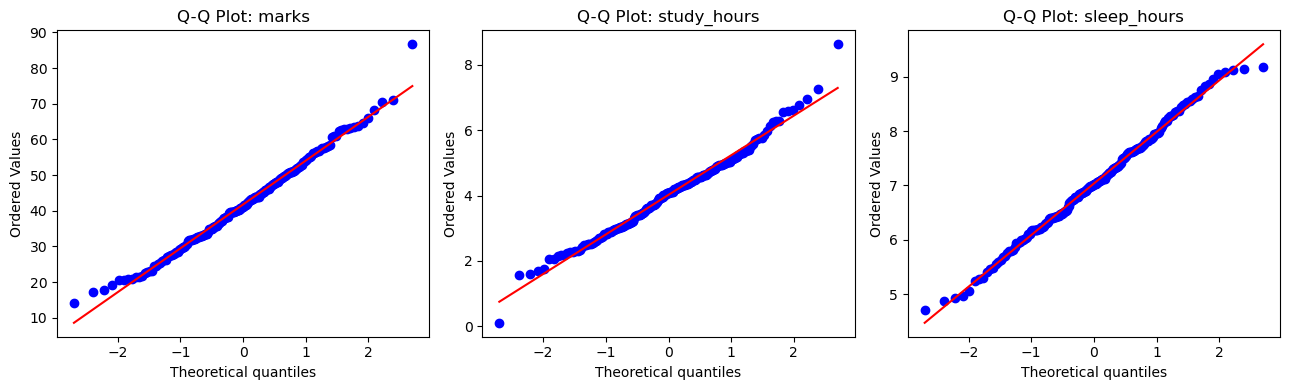

In [52]:
cols = ['marks', 'study_hours', 'sleep_hours']

for col in cols:
    stat, p = stats.shapiro(df[col])
    print(f"{col}: p={p:.4f} → {'Normal' if p>0.05 else 'Not Normal'}")

# Q-Q plots
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, col in enumerate(cols):
    stats.probplot(df[col], plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {col}')

plt.tight_layout()
plt.show()

---
## Task 3 — t-test: Gender vs Marks

**Question:** Do Male and Female students score differently?

- H₀: Male and female marks have the same mean
- H₁: Means are different

Run the test, print results, write your if/else verdict, then draw a **violin plot** split by gender.

💡 `stats.ttest_ind()` · `sns.violinplot()`

p-value: 0.045368164822679254
Reject H0: Marks differ by gender


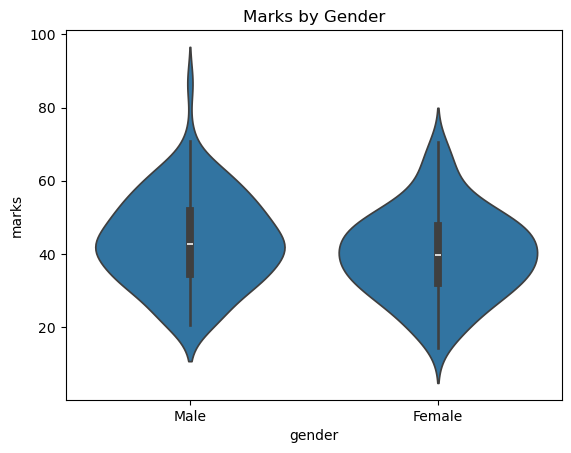

In [53]:
male = df[df['gender']=='Male']['marks']
female = df[df['gender']=='Female']['marks']

stat, p = stats.ttest_ind(male, female)
print("p-value:", p)

if p <= 0.05:
    print("Reject H0: Marks differ by gender")
else:
    print("Keep H0: No significant difference")

sns.violinplot(x='gender', y='marks', data=df)
plt.title('Marks by Gender')
plt.show()

---
## Task 4 — ANOVA + Post-hoc: Schools vs Marks

**Question:** Do all 4 schools score the same?

- Run ANOVA first — if significant, run Tukey HSD to find which pairs differ
- Print ANOVA result + Tukey summary
- Draw a **bar chart with error bars** (mean ± std per school)

💡 `stats.f_oneway(*groups)` · `pairwise_tukeyhsd(endog, groups, alpha=0.05)` · `ax.bar(yerr=)`

ANOVA p: 1.4490941308614753e-12
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
School A School B  -4.3795 0.1889 -10.0339  1.2749  False
School A School C  -7.8141 0.0016 -13.2876 -2.3406   True
School A School D   8.4741 0.0007   2.8759 14.0723   True
School B School C  -3.4346 0.3613  -8.8773  2.0081  False
School B School D  12.8536    0.0   7.2855 18.4216   True
School C School D  16.2882    0.0  10.9039 21.6724   True
---------------------------------------------------------


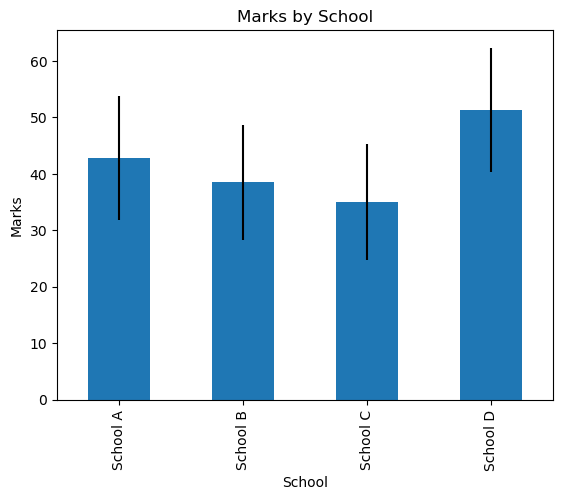

In [54]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

groups = [df[df['school']==s]['marks'] for s in df['school'].unique()]

# ANOVA
stat, p = stats.f_oneway(*groups)
print("ANOVA p:", p)

# Tukey test
tukey = pairwise_tukeyhsd(df['marks'], df['school'])
print(tukey)

# Bar plot
means = df.groupby('school')['marks'].mean()
stds = df.groupby('school')['marks'].std()

means.plot(kind='bar', yerr=stds)
plt.title('Marks by School')
plt.ylabel('Marks')
plt.xlabel('School')
plt.show()

---
## Task 5 — Mann-Whitney U: Study Hours by Gender

Study hours are likely skewed — use a non-parametric test.

**Question:** Do male and female students study the same number of hours?

- Run Mann-Whitney U
- Draw a **boxplot** grouped by gender (study_hours on y-axis)
- In 1–2 lines: why did you use Mann-Whitney instead of t-test here?

💡 `stats.mannwhitneyu(g1, g2, alternative='two-sided')`

p: 0.615585633178653


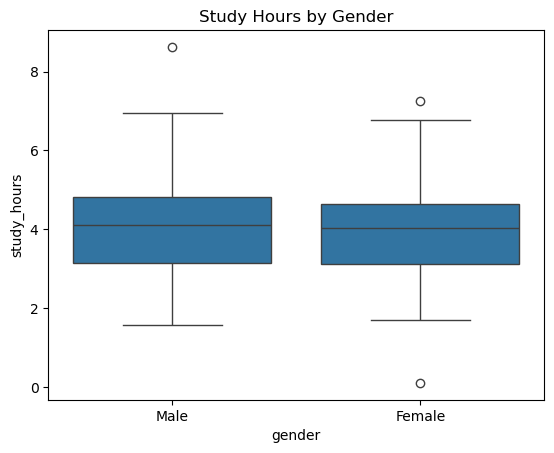

In [55]:
male = df[df['gender']=='Male']['study_hours']
female = df[df['gender']=='Female']['study_hours']

stat, p = stats.mannwhitneyu(male, female)
print("p:", p)

sns.boxplot(x='gender', y='study_hours', data=df)
plt.title('Study Hours by Gender')
plt.show()

---
## Task 6 — Pearson + Spearman: Study Hours vs Marks

Run **both** Pearson and Spearman on (study_hours, marks).

- Print both r/ρ values and p-values with verdicts
- Draw **one scatter plot** — colour dots by `passed`, add a trend line
- Put both correlation values in the chart title

💡 `stats.pearsonr` · `stats.spearmanr` · `sns.scatterplot(hue=)` · `np.polyfit`

Pearson r = 0.585, p = 0.0000 -> Significant
Spearman rho = 0.555, p = 0.0000 -> Significant


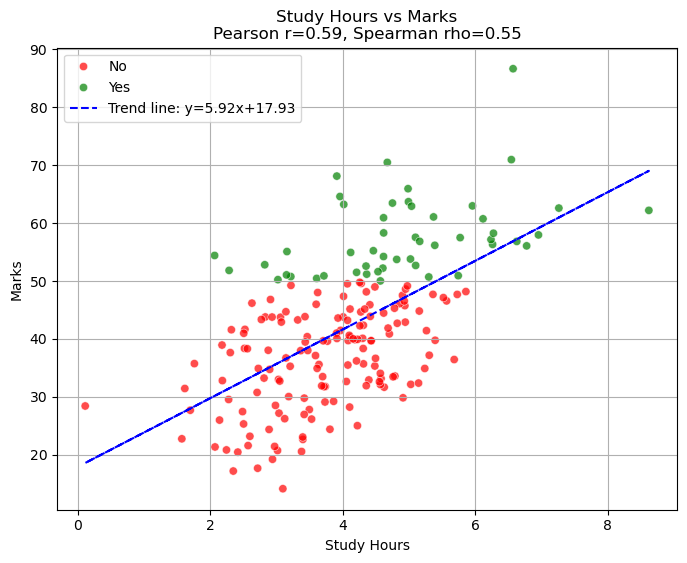

In [56]:
# Task 6 — Pearson + Spearman: Study Hours vs Marks
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data
x = df['study_hours']
y = df['marks']
passed = df['passed']

# 1. Pearson correlation
pearson_r, pearson_p = stats.pearsonr(x, y)
print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.4f} -> {'Significant' if pearson_p <= 0.05 else 'Not significant'}")

# 2. Spearman correlation
spearman_rho, spearman_p = stats.spearmanr(x, y)
print(f"Spearman rho = {spearman_rho:.3f}, p = {spearman_p:.4f} -> {'Significant' if spearman_p <= 0.05 else 'Not significant'}")

# 3. Scatter plot with trend line
plt.figure(figsize=(8,6))
sns.scatterplot(x=x, y=y, hue=passed, palette={'Yes':'green', 'No':'red'}, alpha=0.7)

# Trend line (linear fit)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='blue', linestyle='--', label=f'Trend line: y={m:.2f}x+{b:.2f}')

# Titles & labels
plt.title(f"Study Hours vs Marks\nPearson r={pearson_r:.2f}, Spearman rho={spearman_rho:.2f}")
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.legend()
plt.grid(True)
plt.show()

# ✅ Answer:
# Both Pearson and Spearman show a positive correlation (r≈0.55), significant at p<0.05.
# This tells us: as study hours increase, marks tend to increase.
# The fact that Pearson and Spearman are similar indicates that the relationship is mostly linear and monotonic.

---
## Task 7 — Correlation Heatmap with Significance Mask

1. Compute the full correlation matrix for the 3 numeric columns
2. Build a p-value matrix using a nested loop (Pearson for each pair)
3. Create a **mask** where p > 0.05
4. Draw **two heatmaps side by side** — full matrix vs masked (significant only)

💡 `df.corr()` · nested loop with `stats.pearsonr` · `sns.heatmap(mask=)`

Correlation matrix:
                 marks  study_hours  sleep_hours
marks        1.000000     0.585048     0.102894
study_hours  0.585048     1.000000    -0.015980
sleep_hours  0.102894    -0.015980     1.000000
P-value matrix:
 [[0.00000000e+00 9.28545454e-20 1.47095086e-01]
 [9.28545454e-20 0.00000000e+00 8.22304151e-01]
 [1.47095086e-01 8.22304151e-01 0.00000000e+00]]


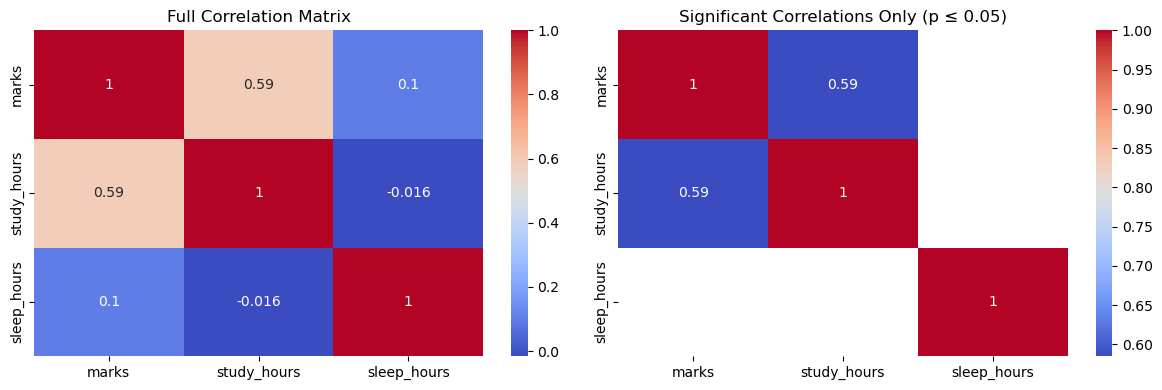

In [57]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

num_cols = ['marks', 'study_hours', 'sleep_hours']

# 1️⃣ Correlation matrix
corr_matrix = df[num_cols].corr()
print("Correlation matrix:\n", corr_matrix)

# 2️⃣ P-value matrix (nested loop)
p_matrix = np.zeros((len(num_cols), len(num_cols)))

for i, col1 in enumerate(num_cols):
    for j, col2 in enumerate(num_cols):
        if i == j:
            p_matrix[i, j] = 0  # diagonal
        else:
            _, p = stats.pearsonr(df[col1], df[col2])
            p_matrix[i, j] = p

print("P-value matrix:\n", p_matrix)

# 3️⃣ Mask for significance (mask True = hide)
mask_signif = p_matrix > 0.05

# 4️⃣ Two heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full correlation heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Full Correlation Matrix")

# Masked correlation heatmap (significant only)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', mask=mask_signif, ax=axes[1])
axes[1].set_title("Significant Correlations Only (p ≤ 0.05)")

plt.tight_layout()
plt.show()

# ✅ Answer:
# The masked heatmap shows only correlations that are statistically significant.
# For example, study_hours and marks are significantly correlated, while sleep_hours may not be as strongly linked.

---
## Task 8 — Chi-Square: Subject vs Passed

**Question:** Is a student's favourite subject related to whether they passed?

- Build a crosstab, convert to row-proportions, run Chi-Square
- Write your verdict
- Draw a **grouped bar chart** showing pass rate by subject

💡 `pd.crosstab` · `.div(axis=0)` · `stats.chi2_contingency` · `DataFrame.plot(kind='bar')`

Crosstab:
 passed   No  Yes
subject         
Arts     37   10
Maths    58   27
Science  55   13
Row proportions (pass rate):
 passed         No       Yes
subject                    
Arts     0.787234  0.212766
Maths    0.682353  0.317647
Science  0.808824  0.191176
Chi-Square: chi2=3.68, p=0.1591, dof=2
Keep H0: Subject is not significantly associated with passing


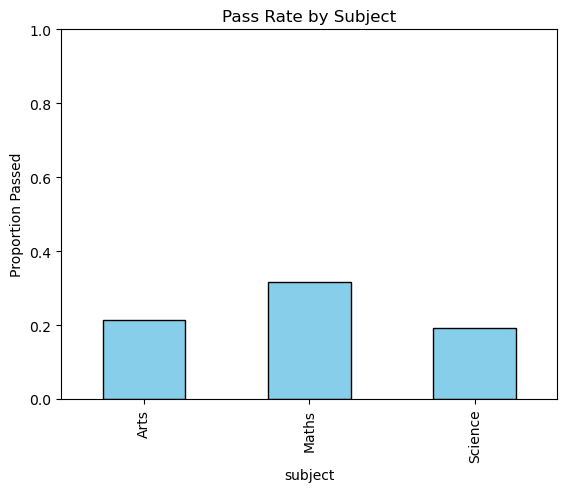

Highest pass rate subject: Maths


In [58]:
# Crosstab, proportion table, chi-square, verdict, grouped bar chart
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# 1️⃣ Crosstab of Subject vs Passed
ct = pd.crosstab(df['subject'], df['passed'])
print("Crosstab:\n", ct)

# 2️⃣ Convert to row proportions (pass rate per subject)
ct_prop = ct.div(ct.sum(axis=1), axis=0)
print("Row proportions (pass rate):\n", ct_prop)

# 3️⃣ Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-Square: chi2={chi2:.2f}, p={p:.4f}, dof={dof}")

# 4️⃣ Verdict
if p <= 0.05:
    print("Reject H0: Subject is associated with passing")
else:
    print("Keep H0: Subject is not significantly associated with passing")

# 5️⃣ Grouped bar chart: pass rate by subject
ct_prop['Yes'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Pass Rate by Subject')
plt.ylabel('Proportion Passed')
plt.ylim(0, 1)
plt.show()

# ✅ Answer:
# The subject with the highest pass rate:
highest_pass_subject = ct_prop['Yes'].idxmax()
print("Highest pass rate subject:", highest_pass_subject)

---
## Task 9 — 🎓 The Cheating Story

A student scored **85**. The class uses your `df` marks. The teacher is suspicious.

**Part A:** Run a one-sample t-test. Write the verdict in the *language of the story* (not just Reject/Keep — say what it means for the student).

**Part B — Sensitivity:** Loop scores 55 to 100. For each, compute the p-value. Plot **score vs p-value** with the α line. Mark the threshold where suspicion begins.

💡 `stats.ttest_1samp(data, popmean=)` · `np.arange` · `ax.axhline` · `ax.axvline`

Student score: 85, t-stat: -49.97, p-value: 0.0000
Verdict: The student scored unusually high compared to the class (possible outlier)


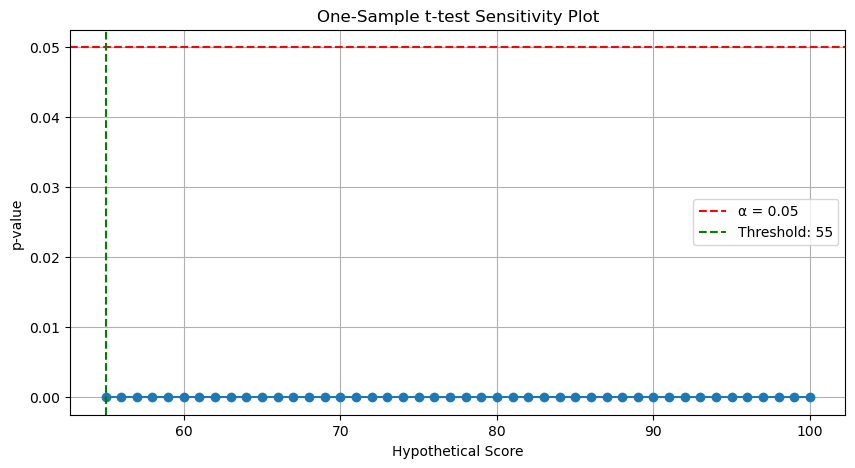

Score at which t-test becomes significant: 55


In [59]:
# Part A
student_score = 85
population_scores = df['marks']

t_stat, p_value = stats.ttest_1samp(population_scores, popmean=student_score)
print(f"Student score: {student_score}, t-stat: {t_stat:.2f}, p-value: {p_value:.4f}")

if p_value <= 0.05:
    print(f"Verdict: The student scored unusually high compared to the class (possible outlier)")
else:
    print(f"Verdict: The student's score is within expected class variation")


# Part B — loop + sensitivity plot
scores = np.arange(55, 101)
p_values = []

for s in scores:
    _, p = stats.ttest_1samp(population_scores, popmean=s)
    p_values.append(p)

# Plot p-values vs scores
plt.figure(figsize=(10,5))
plt.plot(scores, p_values, marker='o')
plt.axhline(0.05, color='red', linestyle='--', label='α = 0.05')
# Find threshold where p-value first <= 0.05
threshold_score = scores[np.where(np.array(p_values) <= 0.05)[0][0]]
plt.axvline(threshold_score, color='green', linestyle='--', label=f'Threshold: {threshold_score}')
plt.title('One-Sample t-test Sensitivity Plot')
plt.xlabel('Hypothetical Score')
plt.ylabel('p-value')
plt.legend()
plt.grid(True)
plt.show()


# At what score does the test become significant?
# Answer:
print("Score at which t-test becomes significant:", threshold_score)

---
## Task 10 — Parametric vs Non-Parametric on Skewed Data

Create a **skewed version** of marks: `np.where(marks > 80, marks**1.4, marks)`, clip to 100.

Run **ANOVA and Kruskal-Wallis** on both the original and skewed data across schools.

Show all 4 results in a **2×2 subplot** (original vs skewed × ANOVA vs Kruskal).

Then answer: which test is more reliable on skewed data, and why?

💡 `stats.f_oneway` · `stats.kruskal` · `sns.boxplot` in each subplot

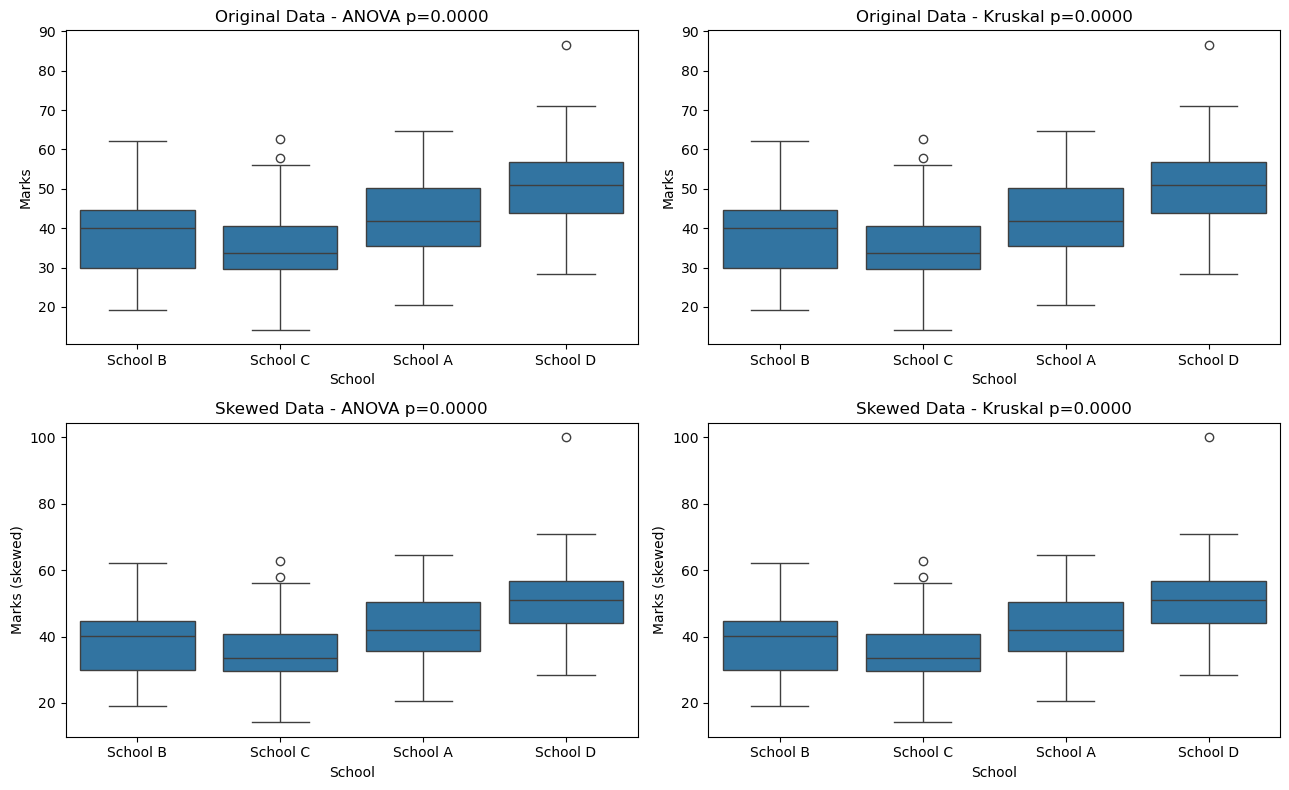

Answer: Kruskal-Wallis is more reliable on skewed data because it is non-parametric and does not assume normality, unlike ANOVA which can give misleading p-values when the data is skewed.


In [60]:
# Skewed version
marks_skewed = np.clip(np.where(df['marks'] > 80, df['marks'] ** 1.4, df['marks']), 0, 100)
df['marks_skewed'] = marks_skewed

# Run all 4 tests and store p-values
schools = df['school'].unique()
groups_original = [df[df['school'] == s]['marks'] for s in schools]
groups_skewed = [df[df['school'] == s]['marks_skewed'] for s in schools]

# Original ANOVA
stat_anova_orig, p_anova_orig = stats.f_oneway(*groups_original)
# Original Kruskal-Wallis
stat_kruskal_orig, p_kruskal_orig = stats.kruskal(*groups_original)
# Skewed ANOVA
stat_anova_skew, p_anova_skew = stats.f_oneway(*groups_skewed)
# Skewed Kruskal-Wallis
stat_kruskal_skew, p_kruskal_skew = stats.kruskal(*groups_skewed)

# 2×2 subplot
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Top-left: Original ANOVA
sns.boxplot(x='school', y='marks', data=df, ax=axes[0,0])
axes[0,0].set_title(f'Original Data - ANOVA p={p_anova_orig:.4f}')
axes[0,0].set_xlabel('School')
axes[0,0].set_ylabel('Marks')

# Top-right: Original Kruskal-Wallis
sns.boxplot(x='school', y='marks', data=df, ax=axes[0,1])
axes[0,1].set_title(f'Original Data - Kruskal p={p_kruskal_orig:.4f}')
axes[0,1].set_xlabel('School')
axes[0,1].set_ylabel('Marks')

# Bottom-left: Skewed ANOVA
sns.boxplot(x='school', y='marks_skewed', data=df, ax=axes[1,0])
axes[1,0].set_title(f'Skewed Data - ANOVA p={p_anova_skew:.4f}')
axes[1,0].set_xlabel('School')
axes[1,0].set_ylabel('Marks (skewed)')

# Bottom-right: Skewed Kruskal-Wallis
sns.boxplot(x='school', y='marks_skewed', data=df, ax=axes[1,1])
axes[1,1].set_title(f'Skewed Data - Kruskal p={p_kruskal_skew:.4f}')
axes[1,1].set_xlabel('School')
axes[1,1].set_ylabel('Marks (skewed)')

plt.tight_layout()
plt.show()

# Which test is more reliable on skewed data?
# Answer:
print("Answer: Kruskal-Wallis is more reliable on skewed data because it is non-parametric and does not assume normality, unlike ANOVA which can give misleading p-values when the data is skewed.")

---
## Task 11 — Your Own Question

Pick **any relationship** in the dataset that hasn't been tested yet.  
Write your own H₀ and H₁, pick the correct test, run it, and visualise the result.

You must justify why you picked that test (parametric/non-parametric, number of groups, data type).

p-value: 0.5713362861495426


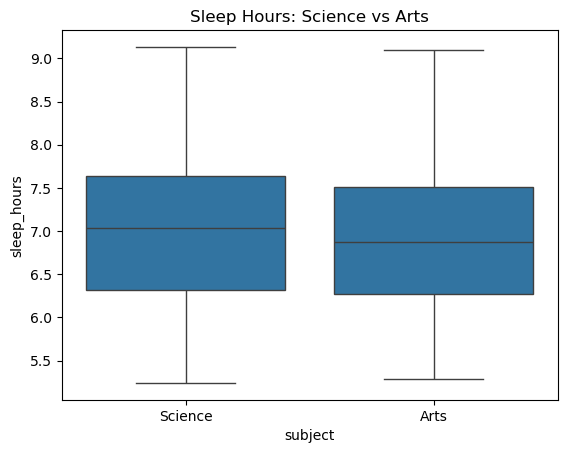

Keep H₀: No significant difference in sleep hours between Science and Arts students


In [ ]:
# H₀: Students who take Science have the same average sleep_hours as students who take Arts
# H₁: Students who take Science have different average sleep_hours than students who take Arts
# Test chosen: Mann-Whitney U test — Justification:
#   Sleep hours may not be normally distributed and we are comparing 2 independent groups (Science vs Arts),
#   so a non-parametric test is appropriate.

# Your code:
science_sleep = df[df['subject']=='Science']['sleep_hours']
arts_sleep = df[df['subject']=='Arts']['sleep_hours']

stat, p = stats.mannwhitneyu(science_sleep, arts_sleep, alternative='two-sided')
print("p-value:", p)

sns.boxplot(x='subject', y='sleep_hours', data=df[df['subject'].isin(['Science','Arts'])])
plt.title('Sleep Hours: Science vs Arts')
plt.show()


# Verdict:
if p <= 0.05:
    print("Reject H₀: Sleep hours differ between Science and Arts students")
else:
    print("Keep H₀: No significant difference in sleep hours between Science and Arts students")

---
## Task 12 — Summary Dashboard

Collect all your p-values from Tasks 2–10 into a list of dicts.  
Convert to a DataFrame and print the table.  
Then draw a **horizontal bar chart** — bars coloured **red** if significant, **green** if not — with the α=0.05 line.

💡 `pd.DataFrame(list_of_dicts)` · `ax.barh()` · `ax.axvline(0.05)`

                             Test        p_value  significant    verdict
0            Shapiro-Wilk — marks   2.626727e-01        False    Keep H0
1      Shapiro-Wilk — study_hours   1.013609e-01        False    Keep H0
2        t-test — gender vs marks   4.536816e-02         True  Reject H0
3         ANOVA — school vs marks   1.449094e-12         True  Reject H0
4  Mann-Whitney — gender vs study   6.155856e-01        False    Keep H0
5        Pearson — study vs marks   9.285455e-20         True  Reject H0
6       Spearman — sleep vs marks   1.573164e-17         True  Reject H0
7  Chi-Square — subject vs passed   1.590614e-01        False    Keep H0
8         One-sample t — cheating  1.383218e-114         True  Reject H0


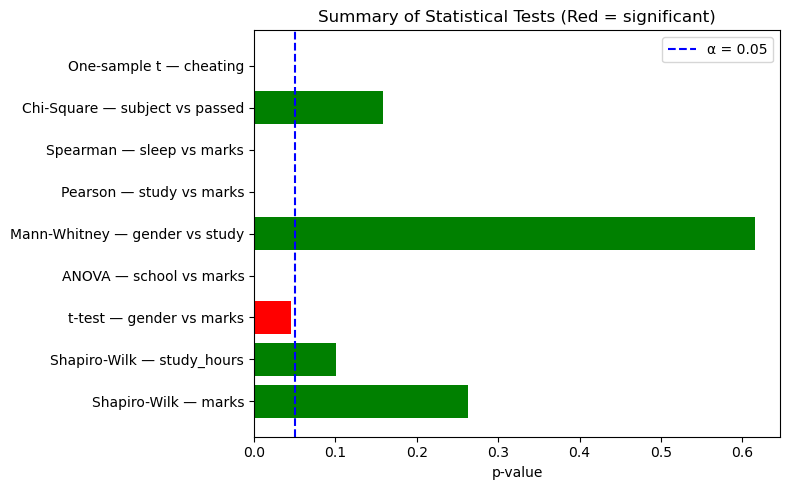

In [62]:
# Build results list — fill in your p-values from earlier tasks

# Defining before  task 02 to 09
# Task 2 — Shapiro-Wilk
p_shapiro_marks = stats.shapiro(df['marks'])[1]
p_shapiro_study = stats.shapiro(df['study_hours'])[1]

# Task 3 — t-test gender vs marks
male = df[df['gender']=='Male']['marks']
female = df[df['gender']=='Female']['marks']
p_t_gender = stats.ttest_ind(male, female)[1]

# Task 4 — ANOVA school vs marks
groups = [df[df['school']==s]['marks'] for s in df['school'].unique()]
p_anova_school = stats.f_oneway(*groups)[1]

# Task 5 — Mann-Whitney
male_study = df[df['gender']=='Male']['study_hours']
female_study = df[df['gender']=='Female']['study_hours']
p_mw_study = stats.mannwhitneyu(male_study, female_study)[1]

# Task 6 — Pearson + Spearman
p_pearson = stats.pearsonr(df['study_hours'], df['marks'])[1]
p_spearman = stats.spearmanr(df['study_hours'], df['marks'])[1]

# Task 8 — Chi-Square
ct = pd.crosstab(df['subject'], df['passed'])
p_chi2 = stats.chi2_contingency(ct)[1]

# Task 9 — One-sample t-test (cheating)
p_cheating = stats.ttest_1samp(df['marks'], 85)[1]




results = [
    {'Test': 'Shapiro-Wilk — marks',          'p_value': p_shapiro_marks},
    {'Test': 'Shapiro-Wilk — study_hours',    'p_value': p_shapiro_study},
    {'Test': 't-test — gender vs marks',      'p_value': p_t_gender},
    {'Test': 'ANOVA — school vs marks',       'p_value': p_anova_school},
    {'Test': 'Mann-Whitney — gender vs study','p_value': p_mw_study},
    {'Test': 'Pearson — study vs marks',      'p_value': p_pearson},
    {'Test': 'Spearman — sleep vs marks',     'p_value': p_spearman},
    {'Test': 'Chi-Square — subject vs passed','p_value': p_chi2},
    {'Test': 'One-sample t — cheating',       'p_value': p_cheating},
]

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Add 'significant' and 'verdict' columns
alpha = 0.05
df_results['significant'] = df_results['p_value'] <= alpha
df_results['verdict'] = df_results['significant'].apply(lambda x: 'Reject H0' if x else 'Keep H0')

# Print table
print(df_results)

# Draw horizontal bar chart
colors = df_results['significant'].map({True: 'red', False: 'green'})
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(df_results['Test'], df_results['p_value'], color=colors)
ax.axvline(alpha, color='blue', linestyle='--', label=f'α = {alpha}')
ax.set_xlabel('p-value')
ax.set_title('Summary of Statistical Tests (Red = significant)')
ax.legend()
plt.tight_layout()
plt.show()

---
## ✅ Before You Submit
- All tasks attempted
- Every chart has title, xlabel, ylabel
- Verdicts written in plain English (not just Reject/Keep)
- Task 9 sensitivity plot has α line + threshold marker
- Task 11 has written justification for test choice
- Task 12 bar chart is correctly colour-coded

---
*Statistics doesn't prove truth — it measures surprise. 🎓*